# Predicting a tournament champion from the group stage — a transparent model

We forecast who wins a knockout tournament using **only the group stage**: three games per team. From those
we build opponent-adjusted attacking / defensive strengths (goals + xG + a learned *threat* model), then
Monte-Carlo the real bracket.

**Read this before believing anything below.** Three games is a tiny sample and knockout football is
high-variance, so *no* model can reliably call the winner. What this one does well is **rank the eventual
champion into a shortlist** — across every World Cup / European Championship in the data it put the champion
in its **top 3 every time**, beating both a naive goal-difference rule and the pre-tournament FIFA #1. On the one
tournament we actually deployed it on — **World Cup 2026** — its #1 pick, Spain, went on to win (see the live
forecast below); a good result, but a single live call, which is why the evidence here leans on the four historical
backtests. What it can't do — including tournaments where its own #1 pick lost early — is spelled out
honestly in the last section. The analysis runs on StatsBomb open data, and every number and figure below is the **baked output of a
real end-to-end run**. The pipeline behind it — event loader, SPADL layer, feature builder, the two learned
models and the simulator — drives a live production deployment and stays private, so this notebook ships as a
read-along record rather than a runnable package; both learned models were trained with every tournament we
evaluate on **held out** (the four backtests, plus Copa América 2024 and AFCON 2023 for good measure).

**Scope.** We validate on the **World Cup + Euro** family — the competition type this model is deployed on
(WC 2026) and the football its components are calibrated on (StatsBomb's coverage is European-heavy). We do
**not** claim it transfers to confederation championships (Copa América, AFCON) or other ecosystems; a
group-stage model tuned in one footballing context should not be assumed to hold in another.

## Setup & data

The run behind this notebook uses **[StatsBomb open data](https://github.com/statsbomb/open-data)** (not
redistributed here; `SB_ROOT` in the setup cell pointed at its `data/` folder). Please follow StatsBomb's
attribution/licence terms.

In [1]:
from pathlib import Path
import json, os, sys
sys.path.insert(0, str(Path.cwd()))          # this folder holds loader/spadl/features/threat/xg/model
sys.path.append(str(Path.cwd().parents[1]))   # repo root — for the house visual standard
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.cm as cm
from matplotlib.colors import Normalize, PowerNorm
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score

from football_visuals.kick_style import *      # house palette / pitch / layout
import model, threat, xg, xt
import spadl, features as F
from loader import load_statsbomb
apply_kick_style()

SB_ROOT = Path(os.environ.get("SB_ROOT", "/path/to/statsbomb_open_data/data"))   # <-- edit me,
#   or leave it and `export SB_ROOT=...`. This repo ships no match data by design.

def load_matches(comp, season):
    return json.load(open(SB_ROOT / "matches" / str(comp) / f"{season}.json", encoding="utf-8"))

# (label, competition_id, season_id, actual champion) — the World Cup / Euro backtest set.
# WC 2026 is the live deployment (not in StatsBomb, so not backtestable here).
TOURNAMENTS = [
    ("WC 2018",   43, 3,   "France"),
    ("WC 2022",   43, 106, "Argentina"),
    ("Euro 2020", 55, 43,  "Italy"),
    ("Euro 2024", 55, 282, "Spain"),
]
n_events = len(list((SB_ROOT / "events").glob("*.json"))) if SB_ROOT.exists() else 0
print(f"StatsBomb open data found: {SB_ROOT.exists()}  ·  {n_events:,} event files")

StatsBomb open data found: True  ·  3,464 event files


## The *threat* model — a gradient-boosted P(score)

For every on-ball action we estimate **V = P(the team scores within the next 10 actions)** with a
`HistGradientBoosting` classifier — 294 boosted trees over 27 features: location, displacement, goal
geometry, action type, whether the action came off, sequence lags and event-only defender-pressure
proxies. Where the ball *ends up* dominates everything else — permuting the end point alone costs 0.18
AUC — and whether the action succeeded is second of the 27, worth 0.06. A player's
**threat** for an action is the positive value it *added*: `max(0, V_i - V_{i-1})` for consecutive same-team
non-shot actions. This is our progression metric, and it beats a textbook Markov *xT* on held-out StatsBomb
actions — **AUC 0.831 vs 0.770**, and **0.826 vs 0.769** on the four backtest tournaments themselves —
computed below rather than asserted.

Penalty goals do **not** count toward the label, so all three danger channels the forecast blends — goals, xG
and threat — are consistently **non-penalty** (a spot-kick isn't open-play attacking quality).

Crucially, the deployed `threat_gbm.pkl` was **trained leave-tournament-out** — every tournament we backtest
is excluded from its training set, so the threat feeding the forecast is never in-sample.

**What threat does not measure.** It credits only the value added between consecutive *same-team*
actions, so a tackle or interception — which by definition follows the opponent's possession — can never
earn threat: the value of a turnover accrues to the first pass after it, not to the action that won the
ball. Defensive quality reaches the forecast by another route entirely, as threat and goals *conceded*.
One feature is also inert on this feed: set-piece phase is derived from Opta qualifiers the StatsBomb
adapter never emits, so every action here is labelled open play.

In [2]:
print("threat GBM — trained EXCLUDING:", threat.EXCLUDED)
print("features:", len(threat.FEAT), "· k =", threat.K)

# demo: per-team threat in one group match (team ids)
demo = load_matches(55, 282)                       # Euro 2024
mid = [m for m in demo if m["competition_stage"]["name"] == "Group Stage"][0]
print("\n", mid["home_team"]["home_team_name"], "vs", mid["away_team"]["away_team_name"])
print("total GBM threat by team id:", threat.match_threat(SB_ROOT / "events" / f"{mid['match_id']}.json"))

threat GBM — trained EXCLUDING: ['WC2018', 'WC2022', 'Euro2020', 'Euro2024', 'Copa2024', 'AFCON2023']
features: 27 · k = 10

 Netherlands vs Austria
total GBM threat by team id: {915: 1.380064698985888, 941: 2.38214687745235}


### What the model actually learned

Textbook xT is a single grid — one number per pitch zone, `V = f(x, y)`. This model is a gradient-boosted
classifier over **27** features, so it doesn't have *a* surface: it has **one per kind of action**. Below is
the whole vocabulary — all thirteen — each swept across the pitch with every non-location feature pinned at *that
action's* own median (the sequence lags follow the swept point), so a panel reads as "a typical
pass / tackle / clearance, taken from here".

Read the peak beside each label first. A pass in front of goal is worth **0.92**; a foul is worth **0.005** —
nearly two hundred times less. The bottom rows barely glow, and that is the result rather than a rendering
fault — to this model *what* you are doing dominates *where* you are doing it, which is exactly the axis a
location-only grid cannot see.
The last panel is the textbook xT surface for comparison; it estimates a different quantity (expected goal
value, not P(score within 10 actions)), so it is drawn on its own scale and the shared colourbar does **not**
apply to it.

A caveat worth stating plainly: each panel is a **slice** of the model, not the model itself — freezing
almost everything but the location is what makes a 27-dimensional function drawable at all.

corpus: 3150 matches · 4,825,681 on-ball actions (3,855,253 train / 970,428 held out)


xT: 12x16 zones · converged in 26 iterations · peak 0.298


surface peaks: Pass 0.923 · Carry 0.854 · Take-on 0.765 · Shot 0.824 · Ball recovery 0.719 · Tackle 0.253 · Interception 0.346 · Aerial 0.033 · Block 0.213 · Clearance 0.105 · Miscontrol 0.072 · Dispossessed 0.074 · Foul 0.005


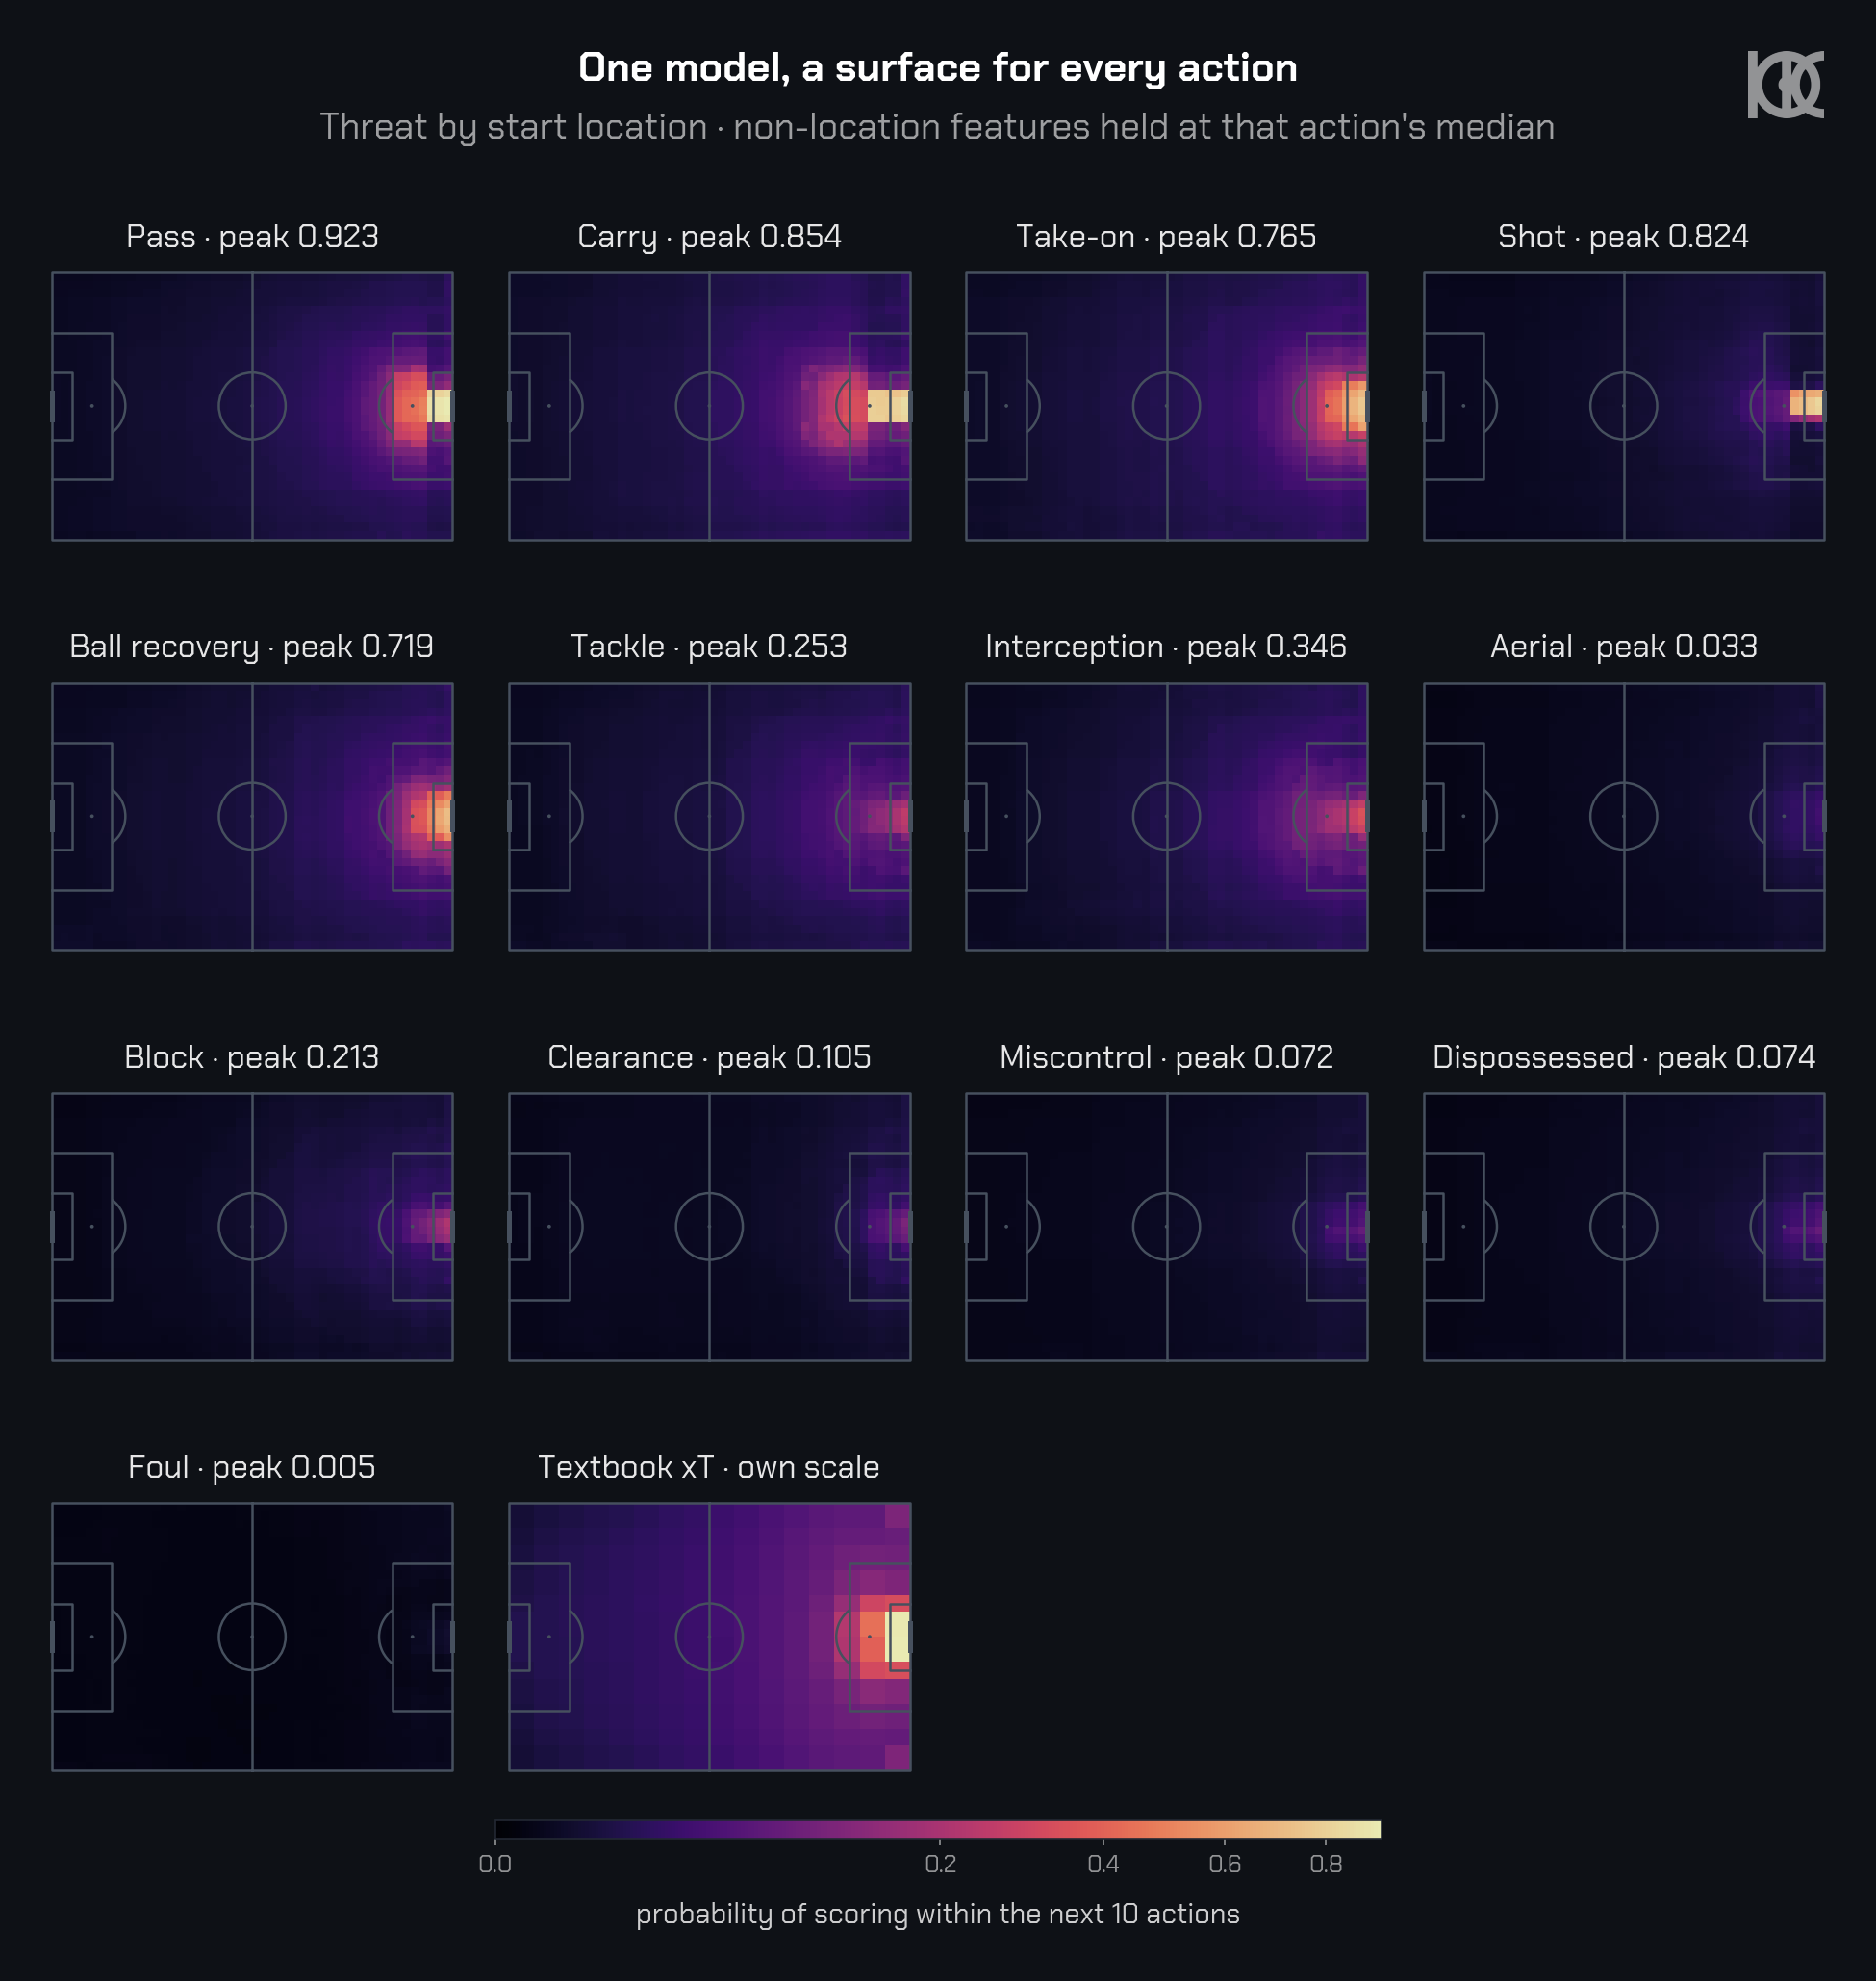

In [3]:
# Corpus for this section: exactly what train_threat_gbm.py learns from — every match except the six
# held-out tournaments (the four backtests + Copa 2024 + AFCON 2023) — with the SAME 1-in-5 test split, so the AUC below reproduces that script's
# printed validation rather than approximating it. ~3150 matches; the featurisation takes a few minutes.
N_CORPUS = None      # None = all of them
HOLDOUT = [("43", "3"), ("43", "106"), ("55", "43"), ("55", "282"), ("223", "282"), ("1267", "107")]
excluded = {m["match_id"] for c, s in HOLDOUT
            for m in json.load(open(SB_ROOT / "matches" / c / f"{s}.json"))}
corpus_ids = [m for m in sorted(int(p.stem) for p in (SB_ROOT / "events").glob("*.json"))
              if m not in excluded]
if N_CORPUS:
    corpus_ids = corpus_ids[:N_CORPUS]

frames, train_rows = [], []
for idx, match_id in enumerate(corpus_ids):
    try:
        rows = spadl.build_labeled(load_statsbomb(SB_ROOT / "events" / f"{match_id}.json"),
                                   k=threat.K, with_carries=True)
        fm = F.featurize_match(rows)
    except Exception:
        continue
    if fm.empty:
        continue
    fm["is_test"] = (idx % 5 == 0)
    frames.append(fm)
    if idx % 5 != 0:
        train_rows.extend(rows)

acts = F.featurize_matches(frames)
acts = acts[acts["sx"].notna() & acts["sy"].notna()].reset_index(drop=True)
train_acts, test_acts = acts[~acts["is_test"]], acts[acts["is_test"]]
print(f"corpus: {len(frames)} matches · {len(acts):,} on-ball actions "
      f"({len(train_acts):,} train / {len(test_acts):,} held out)")

XT = xt.fit_xt(train_rows)                      # textbook Markov xT, fit on the SAME training actions
print(f"xT: {XT['surface'].shape[0]}x{XT['surface'].shape[1]} zones · converged in {XT['iterations']} "
      f"iterations · peak {XT['surface'].max():.3f}")

# --- one surface per action: sweep the start location, hold the rest at THAT ACTION's median
GX, GY = 48, 32
sweep_x = (np.arange(GX) + 0.5) / GX
sweep_y = (np.arange(GY) + 0.5) / GY
mesh_x, mesh_y = (a.ravel() for a in np.meshgrid(sweep_x, sweep_y))
action_cats, phase_cats = acts["action_cat"].cat.categories, acts["phase_cat"].cat.categories
# Per-action medians, not global ones: a clearance's typical displacement, outcome rate and defensive
# context are nothing like a pass's, and pinning them globally would draw a pass wearing a clearance label.
# A feature the action NEVER has (outcome for shots) stays NaN — that IS what the model sees at
# inference; borrowing the global median would feed it a value it never once saw for that action.
med_act = {a: {c: (float(g[c].median()) if g[c].notna().any() else float("nan")) for c in F.NUM_FEATURES}
           for a, g in acts.groupby("action", observed=True)}

def gbm_surface(action):
    """V over the pitch for one action type — a partial-dependence slice of the 27-feature model."""
    med = med_act[action]
    dx, dy = med["dx"], med["dy"]
    n = mesh_x.size
    g = pd.DataFrame({c: np.full(n, med[c]) for c in F.NUM_FEATURES})
    g["sx"], g["sy"] = mesh_x, mesh_y
    g["ex"], g["ey"] = mesh_x + dx, mesh_y + dy
    g["dist"] = np.hypot(dx, dy)
    g["to_goal"] = np.hypot(1.0 - mesh_x, 0.5 - mesh_y)
    g["angle_goal"] = np.arctan2(0.5 - mesh_y, np.clip(1.0 - mesh_x, 1e-3, None))
    g["prev_sx"], g["prev_sy"] = mesh_x, mesh_y
    g["lag2_sx"], g["lag2_sy"] = mesh_x, mesh_y
    g["action_cat"] = pd.Categorical([action] * n, categories=action_cats)
    g["phase_cat"] = pd.Categorical(["open_play"] * n, categories=phase_cats)
    return threat.GBM.predict_proba(g[threat.FEAT])[:, 1].reshape(GY, GX)

# every action in the vocabulary, by row: on the ball · winning it back · blocked or given away
ACTIONS = [("pass", "Pass"), ("carry", "Carry"), ("take_on", "Take-on"), ("shot", "Shot"),
           ("ball_recovery", "Ball recovery"), ("tackle", "Tackle"),
           ("interception", "Interception"), ("aerial", "Aerial"),
           ("block", "Block"), ("clearance", "Clearance"), ("ball_touch", "Miscontrol"),
           ("dispossessed", "Dispossessed"), ("foul", "Foul")]
surfaces = {a: gbm_surface(a) for a, _ in ACTIONS}
print("surface peaks: " + " · ".join(f"{lab} {surfaces[a].max():.3f}" for a, lab in ACTIONS))
xt_grid = xt.xt_value(XT["surface"], mesh_x, mesh_y).reshape(GY, GX)   # same sweep points as the GBM

edges_x, edges_y = np.linspace(0, 120, GX + 1), np.linspace(0, 80, GY + 1)
# PowerNorm: V is ~0 over most of the pitch with a sharp peak at goal, so a linear ramp reads as flat
snorm = PowerNorm(gamma=0.45, vmin=0, vmax=max(s.max() for s in surfaces.values()))
xnorm = PowerNorm(gamma=0.45, vmin=0, vmax=xt_grid.max())     # xT is a different quantity — own scale
panels = [(surfaces[a], f"{lab} · peak {surfaces[a].max():.3f}", snorm) for a, lab in ACTIONS]
panels += [(xt_grid, "Textbook xT · own scale", xnorm)]

pitch, fig, axes = kick_grid(4, 4, line_zorder=3, cbar=True, cbar_pos="bottom")
for ax, panel in zip(axes.flat, panels + [None] * (axes.size - len(panels))):
    if panel is None:
        ax.set_visible(False)                                 # 14 panels in a 4x4 — hide the remainder
        continue
    z, lab, nrm = panel
    m = kick_heatmap(ax, edges_x, edges_y, z, cmap="magma", norm=nrm)
    if nrm is snorm:
        mappable = m                                          # the shared bar describes the GBM panels only
    kick_panel_label(ax, lab)
kick_grid_cbar(fig, axes, mappable, "probability of scoring within the next 10 actions")
kick_grid_title(fig, axes, "One model, a surface for every action",
                "Threat by start location · non-location features held at that action's median")
plt.show()

### Against the textbook baseline

The surfaces show the two models *look* different. This is the test that decides which one is **better**,
and it has to be a fair one. xT scores the expected *goal value* of possession in a zone; this model scores
*P(the team scores within the next 10 actions)* — different quantities on different scales, so they cannot
be compared number to number. Instead we make both predict the same thing: score each on the identical
held-out actions against the identical label, and compare AUC. A location-only lookup against a model that
also knows *what* the action was, where it was going, whether it came off, and what the defence was doing.

In [4]:
# the fair test: same held-out actions, same label, both as scorers
y_true = test_acts["scores_next_k"].astype(int)
p_gbm = threat.GBM.predict_proba(test_acts[threat.FEAT])[:, 1]
p_xt = xt.xt_value(XT["surface"], test_acts["sx"].to_numpy(), test_acts["sy"].to_numpy())
auc_gbm, auc_xt = roc_auc_score(y_true, p_gbm), roc_auc_score(y_true, p_xt)

print(f"held-out actions: {len(y_true):,}   ·   base rate {100 * y_true.mean():.2f}%\n")
print(f"  {f'GBM threat ({len(threat.FEAT)} features)':32s} AUC {auc_gbm:.3f}")
print(f"  {'textbook xT (location only)':32s} AUC {auc_xt:.3f}")
print(f"\n  the learned model adds {auc_gbm - auc_xt:+.3f} AUC over a location-only lookup")

# --- harder still: the four BACKTEST tournaments — fully outside the corpus both models fit on
bt_frames = []
for c, s in [("43", "3"), ("43", "106"), ("55", "43"), ("55", "282")]:
    for m in json.load(open(SB_ROOT / "matches" / c / f"{s}.json")):
        try:
            fm = F.featurize_match(spadl.build_labeled(
                load_statsbomb(SB_ROOT / "events" / f"{m['match_id']}.json"), k=threat.K, with_carries=True))
        except Exception:
            continue
        if not fm.empty:
            bt_frames.append(fm)
bt = F.featurize_matches(bt_frames)
bt = bt[bt["sx"].notna() & bt["sy"].notna()].reset_index(drop=True)
y_bt = bt["scores_next_k"].astype(int)
auc_bt_gbm = roc_auc_score(y_bt, threat.GBM.predict_proba(bt[threat.FEAT])[:, 1])
auc_bt_xt = roc_auc_score(y_bt, xt.xt_value(XT["surface"], bt["sx"].to_numpy(), bt["sy"].to_numpy()))
print(f"\n  and on the four backtest tournaments themselves ({len(bt_frames)} matches, fully out-of-domain):")
print(f"  {'GBM threat':32s} AUC {auc_bt_gbm:.3f}")
print(f"  {'textbook xT':32s} AUC {auc_bt_xt:.3f}")

held-out actions: 970,428   ·   base rate 1.31%

  GBM threat (27 features)         AUC 0.831
  textbook xT (location only)      AUC 0.770

  the learned model adds +0.061 AUC over a location-only lookup



  and on the four backtest tournaments themselves (230 matches, fully out-of-domain):
  GBM threat                       AUC 0.826
  textbook xT                      AUC 0.769


### One match, action by action

The ratings the forecast consumes are just these per-action values summed by team. Below is the demo match
from the top of this section, with each side's most threatening actions drawn from where the ball was to
where it went. **Colour is the kind of action, opacity is the threat it added**, and each arrow tapers from a
hairline at its origin to full weight at its head, so thirty-five overlapping moves still read directionally
instead of turning into a hatch. Actions StatsBomb logs without an end point — a ball recovery, a take-on —
would be zero-length arrows, so they are drawn as dots rather than vanishing. Both sides attack **upward**, so
the two panels are directly comparable, and each panel's total is the number the pipeline actually uses.


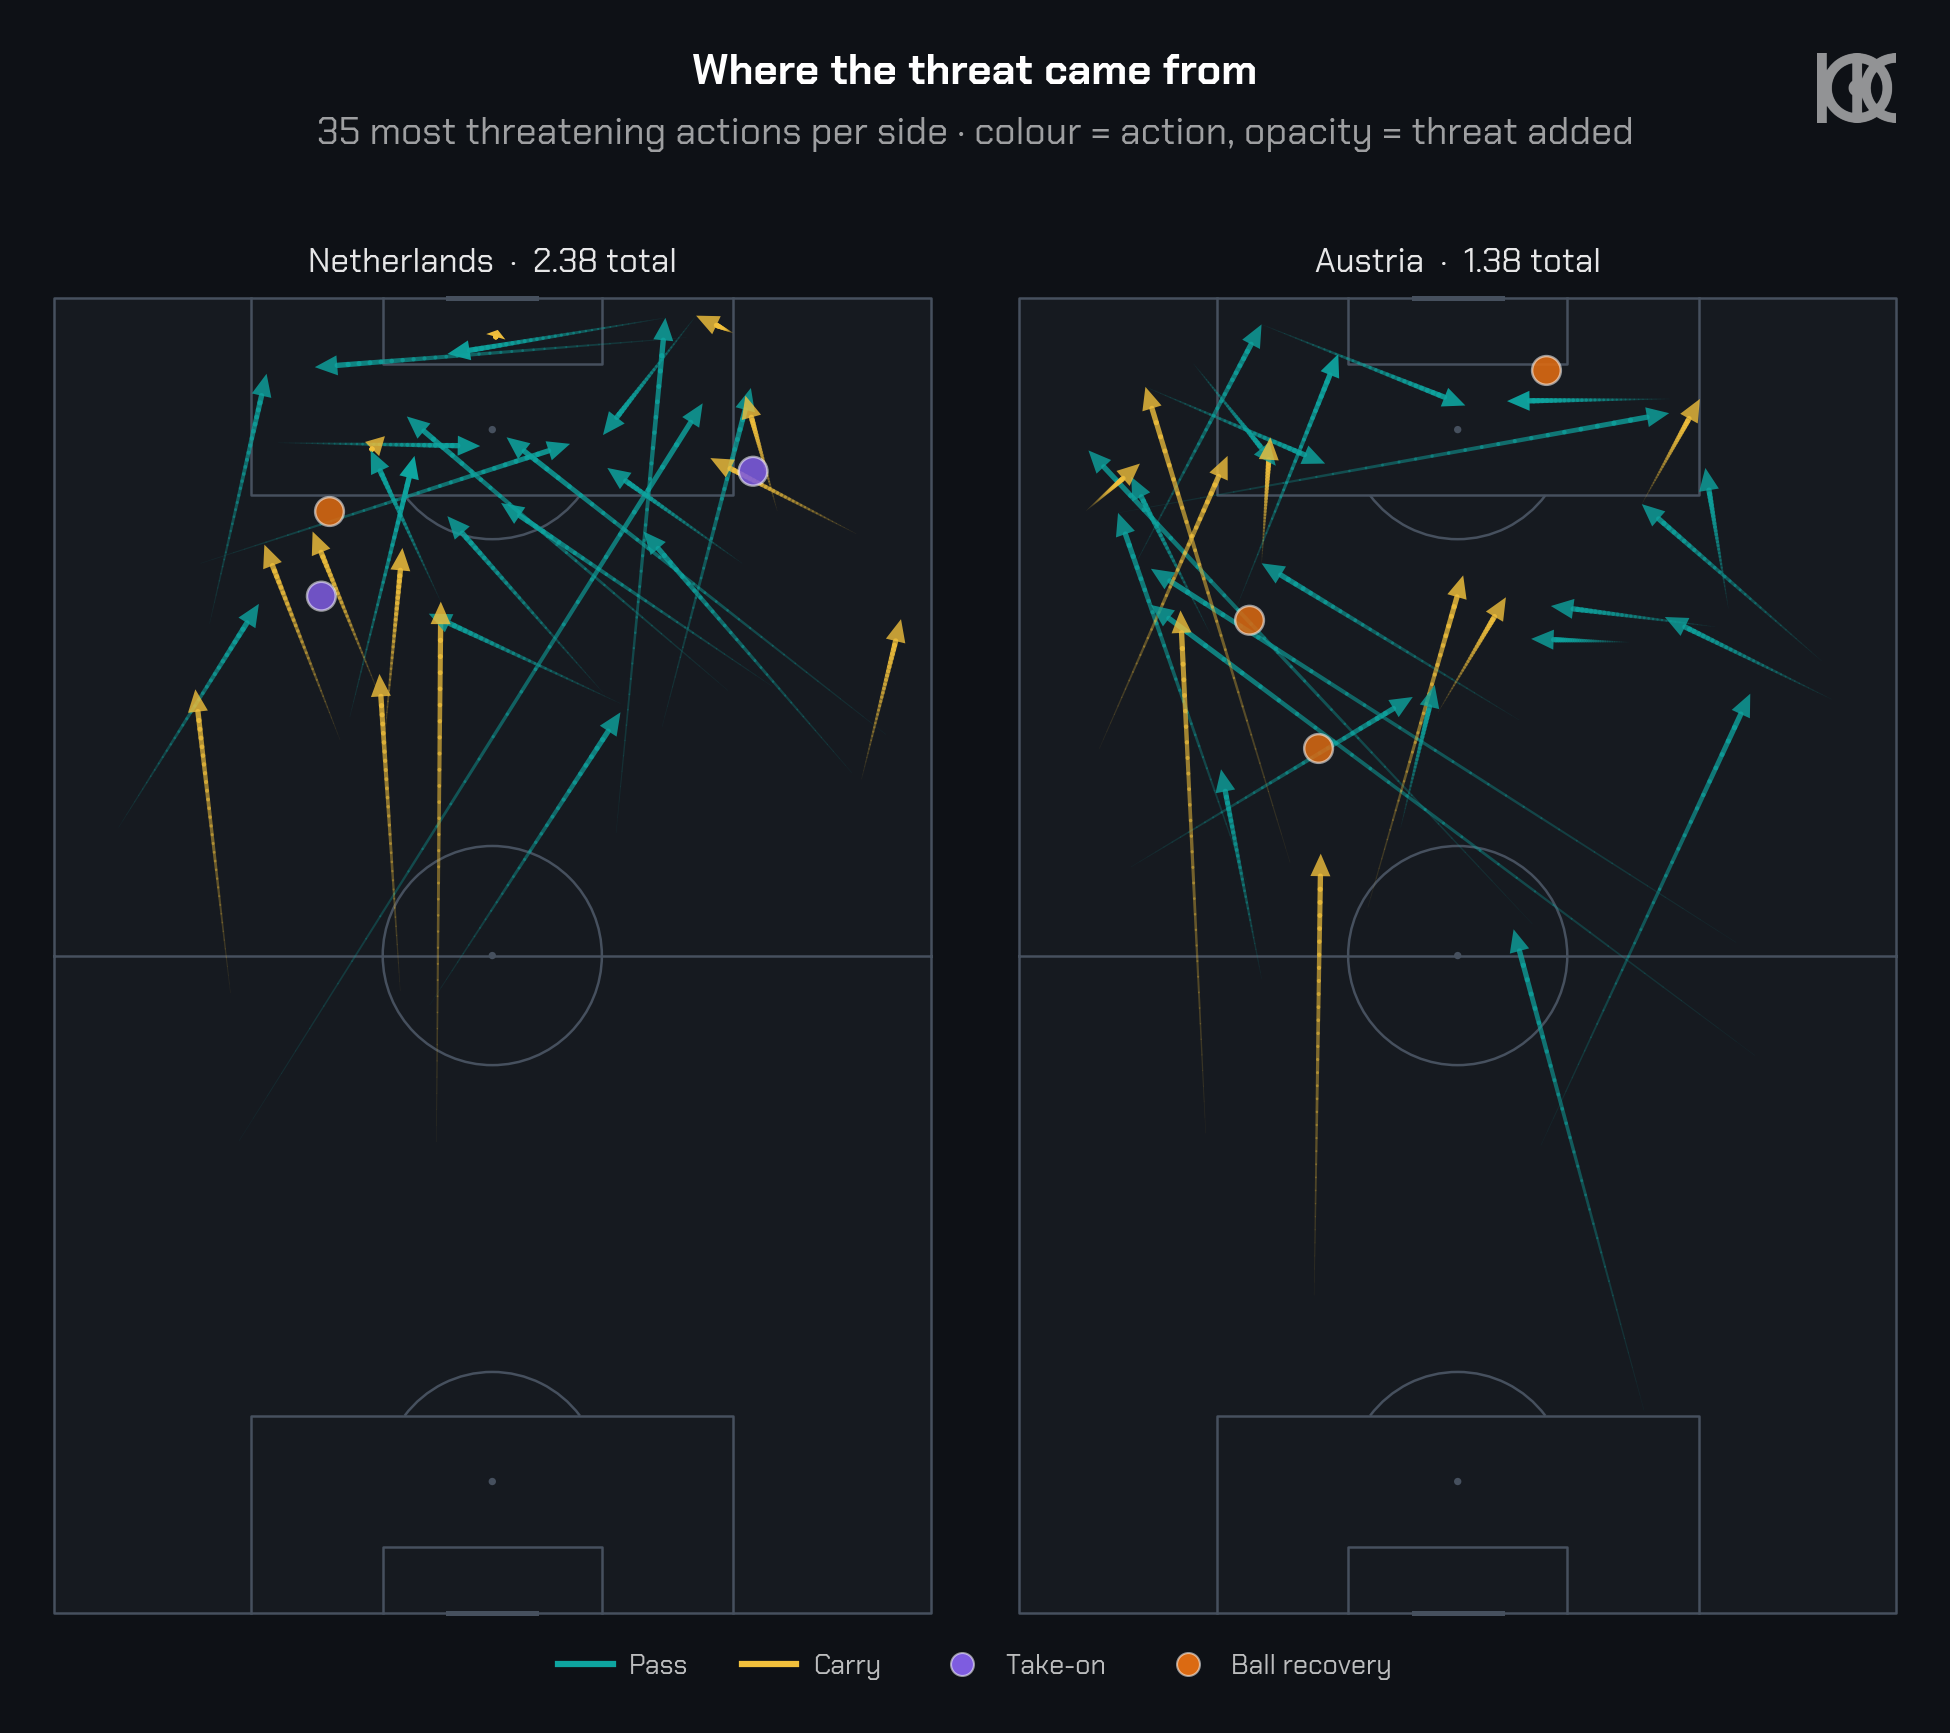

In [5]:
TOP_N = 35     # every positive action is spaghetti (hundreds of them); the story is the dangerous ones
teams = {mid["home_team"]["home_team_id"]: mid["home_team"]["home_team_name"],
         mid["away_team"]["away_team_id"]: mid["away_team"]["away_team_name"]}
av = threat.action_values(load_statsbomb(SB_ROOT / "events" / f"{mid['match_id']}.json"))
av = av[av["threat"] > 0]                          # featurize fills ex/ey from sx/sy, never NaN here
top = {tid: av[av["team"] == tid].nlargest(TOP_N, "threat") for tid in teams}

# Colour carries WHAT the action was, not how big it was: threat is so skewed (the median positive
# action adds ~1% of the match's biggest) that a single-hue ramp collapses to one flat tone.
# Magnitude survives as opacity.
ACT_COLOR = {"pass": KICK["teal"], "carry": KICK["accent"], "take_on": KICK["purple"],
             "ball_recovery": KICK["home"], "interception": KICK["green"], "tackle": KICK["away"]}
ACT_LABEL = {"pass": "Pass", "carry": "Carry", "take_on": "Take-on", "ball_recovery": "Ball recovery",
             "interception": "Interception", "tackle": "Tackle"}
colour = lambda a: ACT_COLOR.get(a, KICK["ink_soft"])
label = lambda a: ACT_LABEL.get(a, a.replace("_", " ").capitalize())

drawn = pd.concat(top.values())
present = list(drawn["action"].unique())            # read the types off the data — never silently drop one
# StatsBomb records an end location ONLY for passes, carries and shots; everything else is a POINT
# event whose end defaults to its start. Drawn as an arrow that is zero-length and so invisible —
# a ball recovery could be the most threatening action of the match and never appear. Dots for those.
moved_all = ~(np.isclose(drawn["ex"], drawn["sx"]) & np.isclose(drawn["ey"], drawn["sy"]))
mv = [a for a in present if ((drawn["action"] == a) & moved_all).any()]
pt = [a for a in present if ((drawn["action"] == a) & ~moved_all).any()]
tmax = float(drawn["threat"].max())

pitch, fig, axes = kick_grid(1, 2, vertical=True, legend_band=0.44)
for ax, (tid, name) in zip(axes.flat, teams.items()):
    d = top[tid].sort_values("threat")
    moved = ~(np.isclose(d["ex"], d["sx"]) & np.isclose(d["ey"], d["sy"]))
    for a in present:
        s = d[(d["action"] == a) & moved]
        if not s.empty:
            # tapered: a hairline where the move started, full weight at the head, so 35 overlapping
            # arrows still read directionally instead of turning into a hatch of equal-weight bars
            kick_taper_arrows(pitch, ax, s["sx"] * 120, s["sy"] * 80, s["ex"] * 120, s["ey"] * 80,
                              colour(a), alpha=0.74 + 0.26 * (s["threat"].to_numpy() / tmax) ** 0.5)
        q = d[(d["action"] == a) & ~moved]
        if not q.empty:
            alpha = 0.82 + 0.18 * (q["threat"].to_numpy() / tmax) ** 0.5
            pitch.scatter(q["sx"] * 120, q["sy"] * 80, ax=ax, s=190, marker="o",
                          c=[to_rgba(colour(a), al) for al in alpha],
                          edgecolors=W(0.55), linewidths=1.2, zorder=5)
    kick_panel_label(ax, f"{name}  ·  {av[av['team'] == tid]['threat'].sum():.2f} total")
handles = [Line2D([0], [0], color=colour(a), lw=3, label=label(a)) for a in mv]
handles += [Line2D([0], [0], color="none", marker="o", markerfacecolor=colour(a),
                   markeredgecolor=W(0.55), markersize=11, label=label(a)) for a in pt]
kick_flat_legend(fig, handles, loc="bottom")
kick_grid_title(fig, axes, "Where the threat came from",
                f"{TOP_N} most threatening actions per side · colour = action, opacity = threat added")
plt.show()

## xG — StatsBomb's when we have it, a *student* when we don't

xG (chance quality) enters both the attack blend and the defensive rating. We use a **conditional**:

* **StatsBomb data present** → use StatsBomb's own `statsbomb_xg` (it sees freeze-frame geometry — defenders,
  keeper — the reference).
* **otherwise** (a live Opta feed, e.g. the real WC26 deployment) → our **student** `xg_student.pkl`: a plain
  logistic model on the features Opta *can* see (distance, angle, body part, assisted, free-kick), distilled to
  approximate StatsBomb xG. It's weaker by exactly the freeze-frame gap it can't observe (**AUC ≈ 0.77 vs
  StatsBomb's ≈ 0.79**, measured at training time). Penalties are excluded from both (free kicks stay
  in — the shot set is *non-penalty*, and `free_kick` is one of the student's features).

Below: what the student believes about every shot location (the two geometric drivers, distance and
angle, dominate — the body part shifts the whole surface), and then the student against its teacher on
real shots **it never trained on**. The scatter is the honest part: the student tracks StatsBomb closely for ordinary chances
but **scatters badly on the big ones**, because whether a six-yard chance is a tap-in or a crowd of
defenders is exactly the freeze-frame geometry it cannot see.


StatsBomb xG by team id : {941: 1.51, 915: 1.06}
student   xG by team id : {941: 1.41, 915: 1.06}


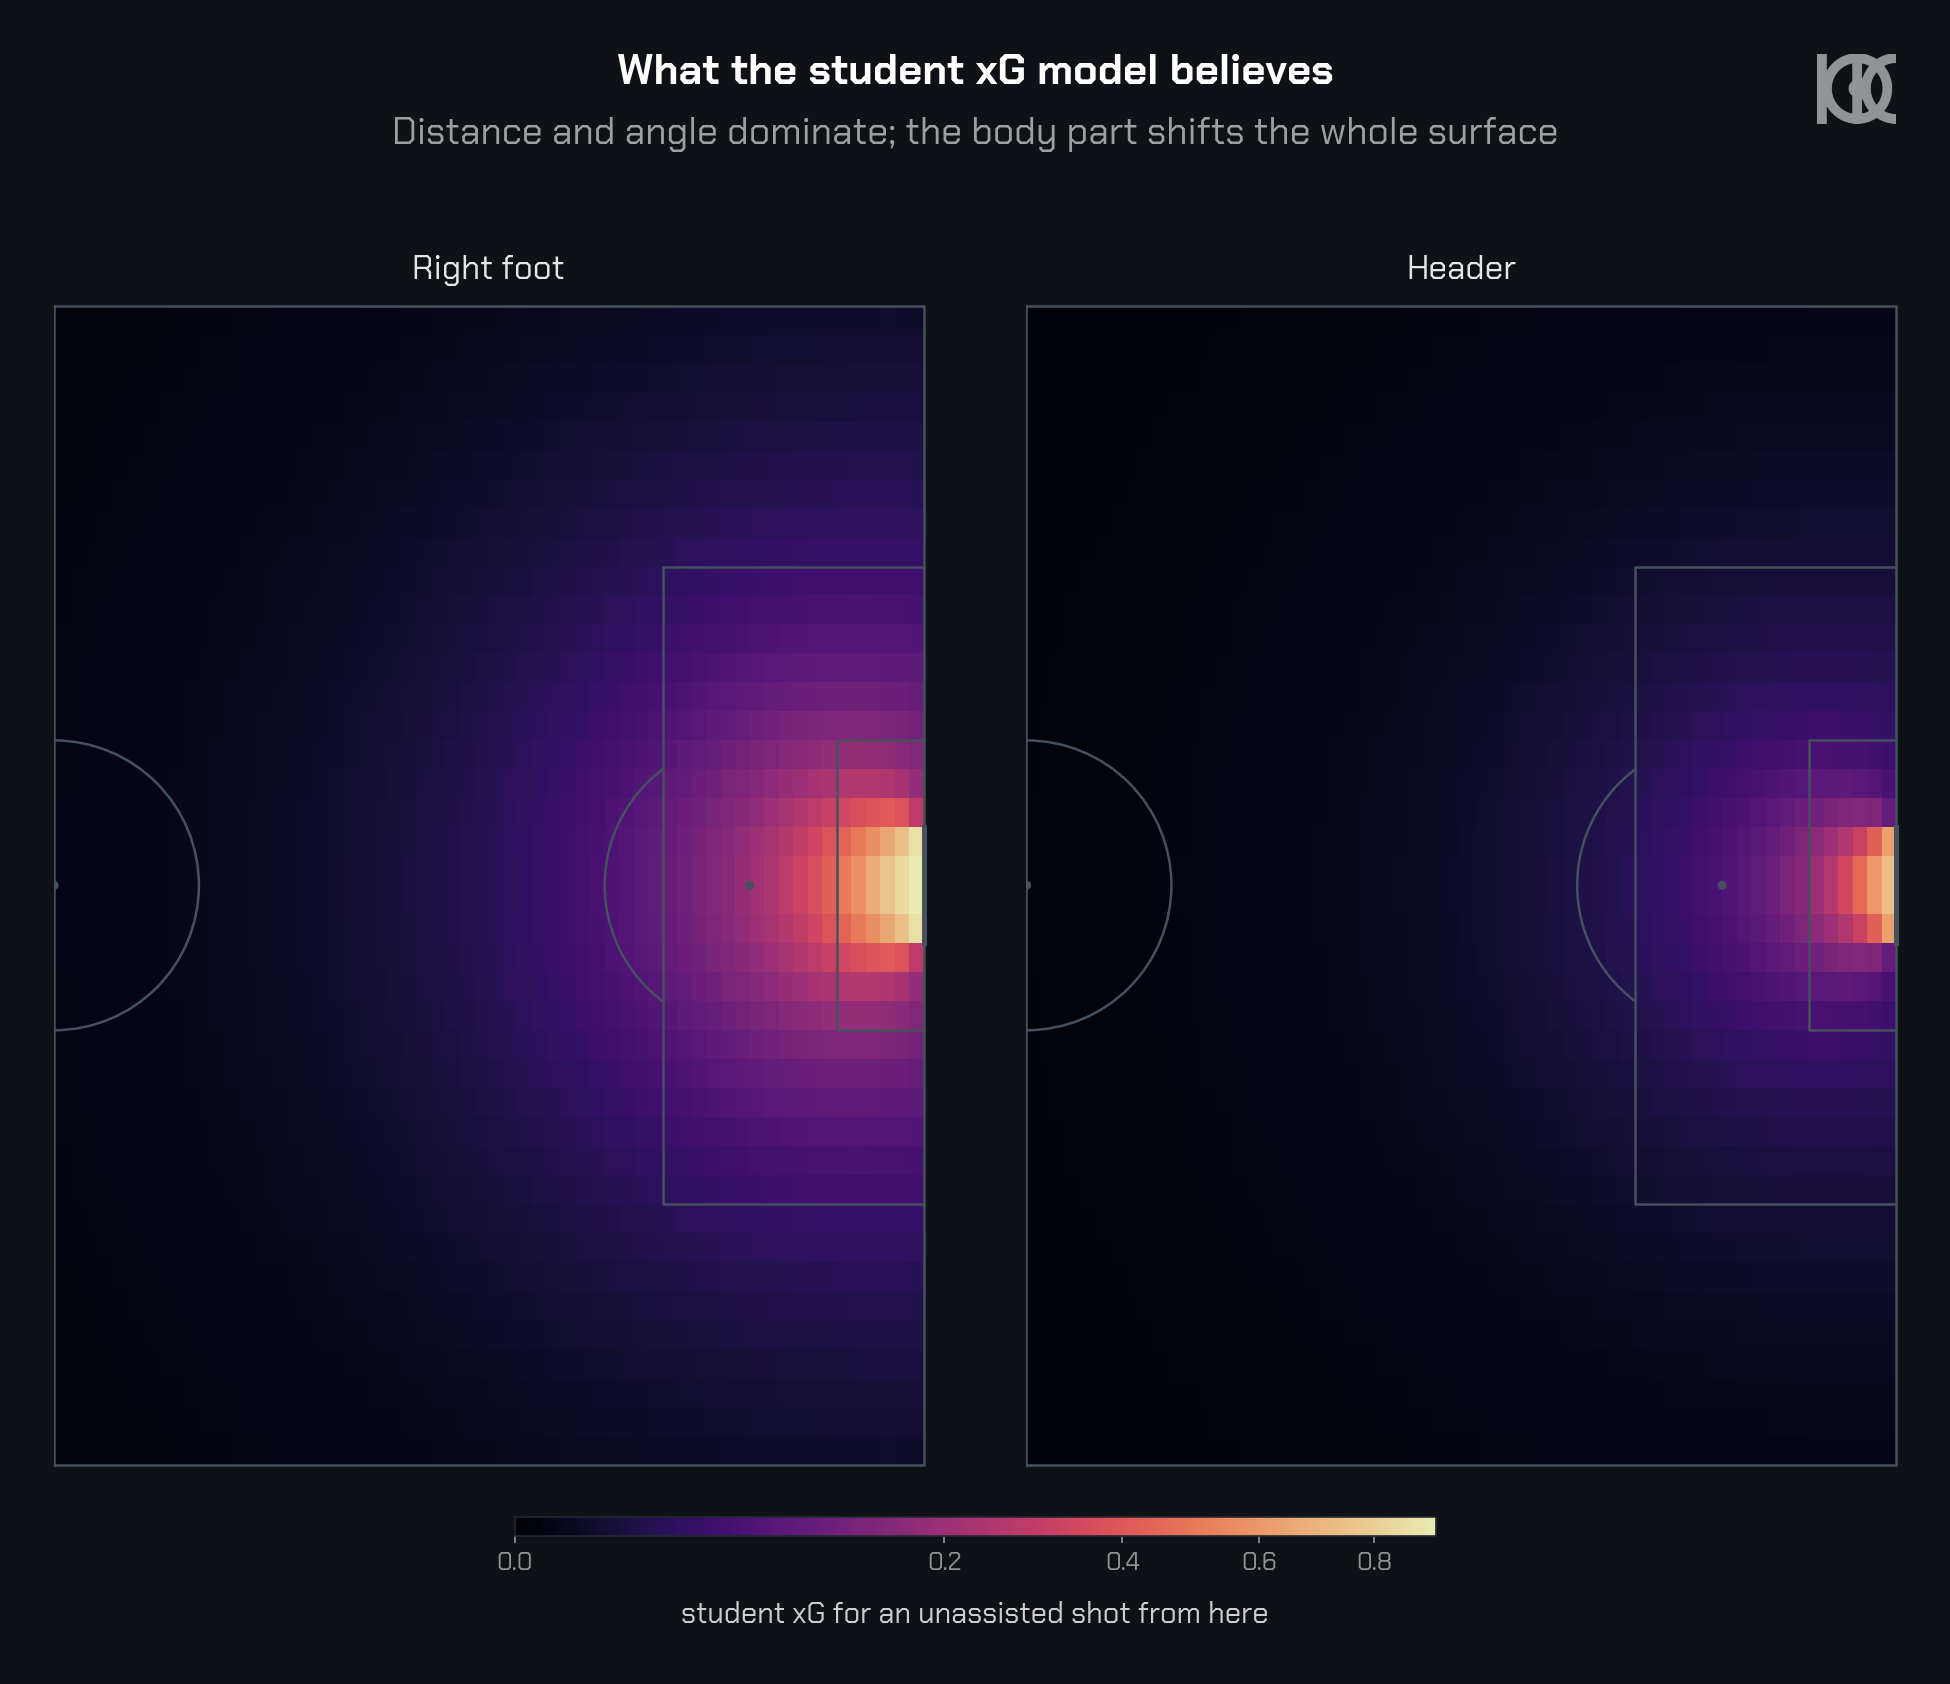

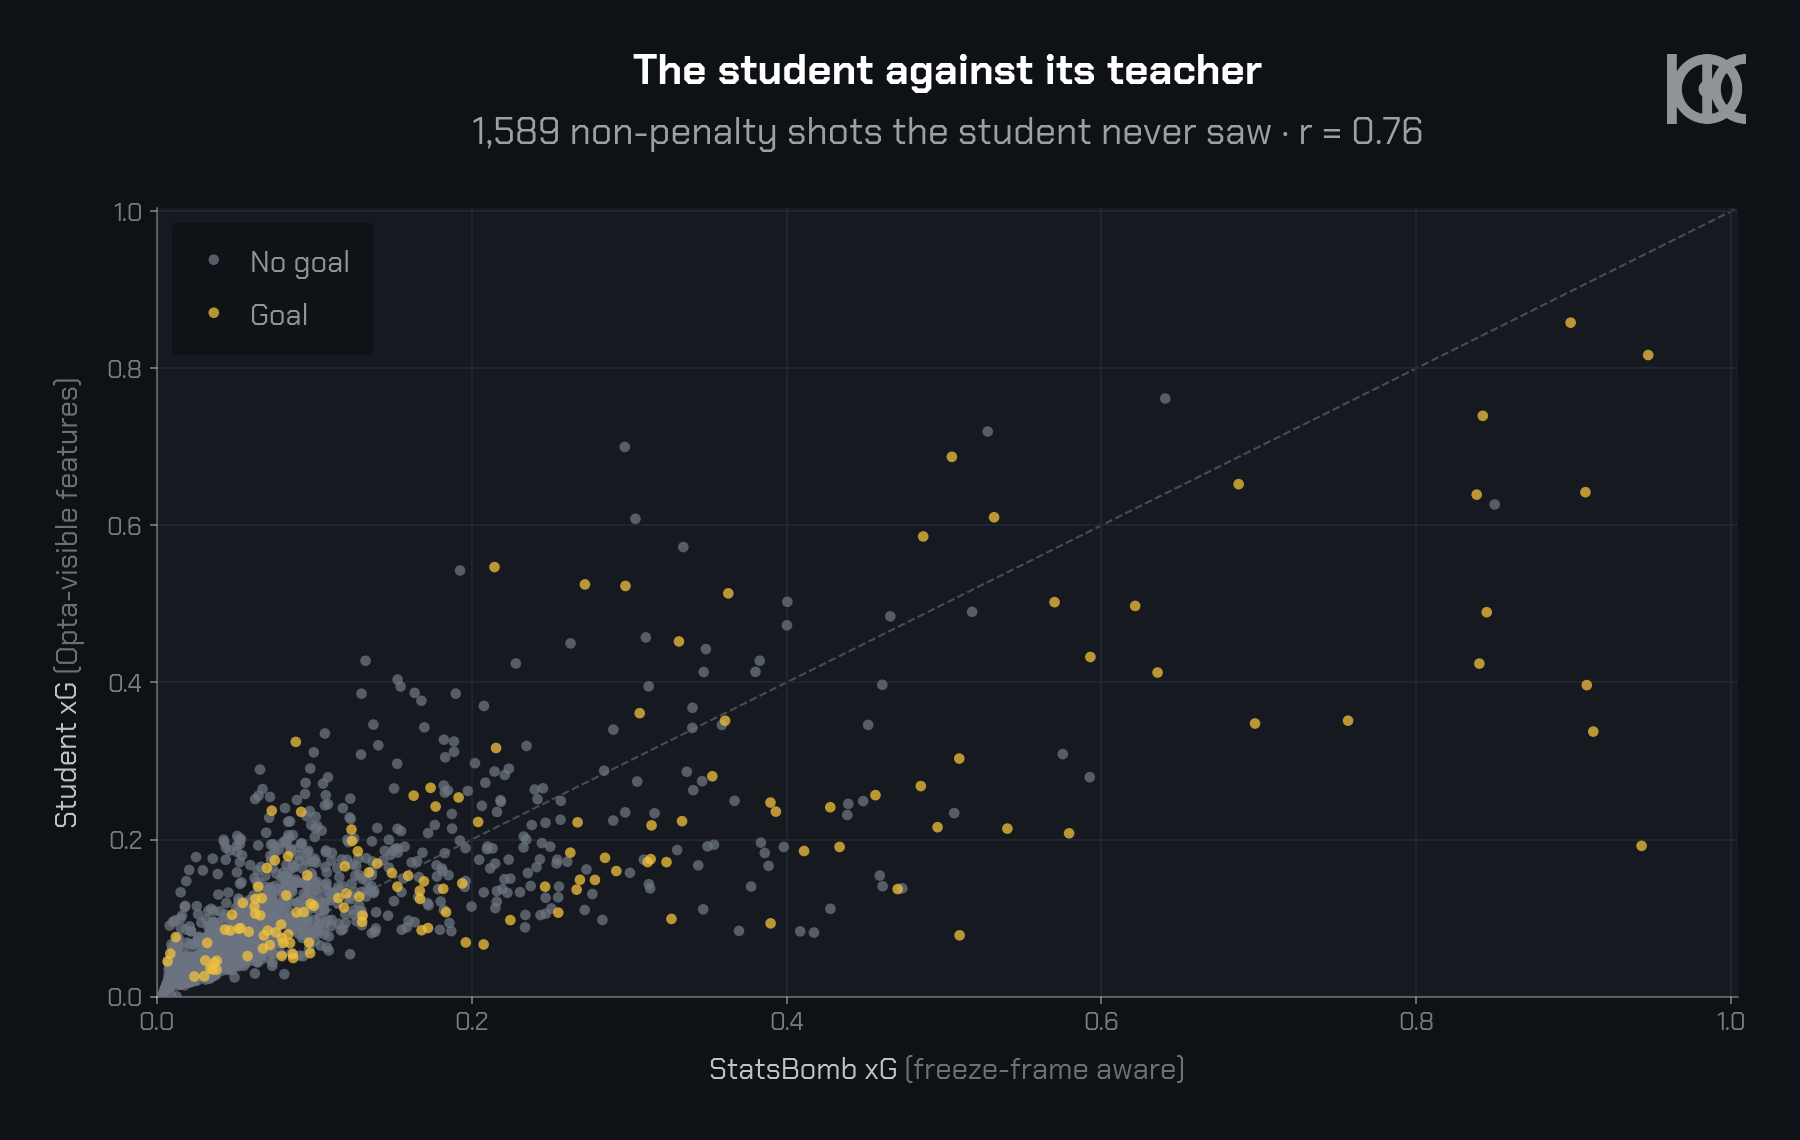

In [6]:
events = json.load(open(SB_ROOT / "events" / f"{mid['match_id']}.json", encoding="utf-8"))
print("StatsBomb xG by team id :", {k: round(v, 2) for k, v in xg.statsbomb_match_xg(events).items()})
print("student   xG by team id :", {k: round(v, 2) for k, v in xg.student_match_xg(events).items()})

# --- what the student actually believes: sweep every shot location, hold the context fixed
stu = xg._load_student()
GXs, GYs = 60, 40
shot_x = 60.0 + (np.arange(GXs) + 0.5) * (60.0 / GXs)   # CELL CENTRES — sampling x=120 exactly would put
shot_y = (np.arange(GYs) + 0.5) * (80.0 / GYs)          # the shot ON the goal line, where the goal
sxm, sym = (a.ravel() for a in np.meshgrid(shot_x, shot_y))   # subtends pi and xG degenerates to ~1
gdx = 120.0 - sxm
shot_dist = np.hypot(gdx, 40.0 - sym)
shot_angle = np.abs(np.arctan2(sym - 36.0, gdx) - np.arctan2(sym - 44.0, gdx))

def student_surface(head):
    X = np.column_stack([shot_dist, shot_angle, np.full(sxm.size, head), np.zeros(sxm.size),
                         np.full(sxm.size, 0 if head else 1), np.zeros(sxm.size), np.zeros(sxm.size)])
    return stu.predict_proba(X)[:, 1].reshape(GYs, GXs)

xg_panels = [(student_surface(0), "Right foot"), (student_surface(1), "Header")]
xg_norm = PowerNorm(gamma=0.5, vmin=0, vmax=max(p[0].max() for p in xg_panels))
xg_ex, xg_ey = np.linspace(60, 120, GXs + 1), np.linspace(0, 80, GYs + 1)
pitch, fig, axes = kick_grid(1, 2, line_zorder=3, cbar=True, cbar_pos="bottom", half=True)
for ax, (z, lab) in zip(axes.flat, xg_panels):
    mappable = kick_heatmap(ax, xg_ex, xg_ey, z, cmap="magma", norm=xg_norm)
    kick_panel_label(ax, lab)
kick_grid_cbar(fig, axes, mappable, "student xG for an unassisted shot from here")
kick_grid_title(fig, axes, "What the student xG model believes",
                "Distance and angle dominate; the body part shifts the whole surface")
plt.show()

# --- the student against its teacher, on real shots
pairs = []
# The student trained on the first 900 corpus matches (train_student_xg.py) — sampling beyond them
# means every shot below is one the student never saw.
for shot_mid in corpus_ids[900:960]:
    try:
        evs = json.load(open(SB_ROOT / "events" / f"{shot_mid}.json", encoding="utf-8"))
    except Exception:
        continue
    for e, sh in xg._non_penalty_shots(evs):
        if sh.get("statsbomb_xg") is None or not e.get("location"):
            continue
        f = xg.shot_features(e)
        pairs.append((sh["statsbomb_xg"],
                      float(stu.predict_proba([[f[k] for k in xg.STUDENT_FEATURES]])[0, 1]),
                      (sh.get("outcome") or {}).get("name") == "Goal"))
P = pd.DataFrame(pairs, columns=["sb", "student", "goal"])

fig, ax = plt.subplots(figsize=(12.0, 7.6)); fig.set_facecolor(KICK["figure"])
ax.set_facecolor(KICK["panel"])
lim = float(P[["sb", "student"]].to_numpy().max()) * 1.06
ax.plot([0, lim], [0, lim], color=W(0.22), ls="--", lw=1, zorder=1)
for flag, col, lab in [(False, KICK["muted"], "No goal"), (True, KICK["accent"], "Goal")]:
    s = P[P["goal"] == flag]
    ax.scatter(s["sb"], s["student"], s=26, c=col, edgecolors="none", alpha=0.75, zorder=3, label=lab)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("StatsBomb xG (freeze-frame aware)")
ax.set_ylabel("Student xG (Opta-visible features)")
ax.grid(True)
kick_inside_legend(ax, loc="upper left")
kick_title(fig, ax, "The student against its teacher",
           f"{len(P):,} non-penalty shots the student never saw · r = {P['sb'].corr(P['student']):.2f}", pitch=False)
plt.show()

## The champion pipeline — step by step

`model.forecast` chains five transparent steps (all in `model.py`):

1. **records** — per team: non-penalty goals, xG, GBM threat, possessions, and each match's row.
2. **opponent adjustment** (leave-one-out) — divide each match's danger by the *opponent's* rate in their
   **other** games, so hammering a weak group isn't rewarded. Rates are **absolute** (danger per possession vs
   the league), which is what lets us compare across groups that never play each other.
3. **strengths** — attack & defense-weakness multipliers (avg team = 1.0), from a goals-led blend, then shrunk
   toward the mean by **empirical Bayes** — a *data-derived* shrink (goals over 3 games are mostly noise and
   shrink hard; xG is better-measured and keeps its spread). No hand-tuned shrink constant — though one small
   hand-set piece follows it: a **bounded goal-difference-consistency tweak** (at most ±10%) that nudges teams
   with streaky score-lines down and steady ones up.
4. **simulate** — `λ = avg_goals · attack · opponent_defWeak`, independent Poisson, draws go to extra time
   (`λ/3`) then 50/50 penalties; fold the **real bracket** 20 000 times. `model.bracket_order`
   reconstructs the actual tree by walking back from the final through the tournament's own fixtures, so
   the first-round ties are the ties that were really played and every later meeting is one that could
   really have happened. **The draw is part of the forecast**, not an afterthought: a team's path matters
   as much as its quality, and the ties are printed below so you can check them against the record.
5. **bootstrap** — resample each team's three games to get honest confidence bands.

Let's run it on **Euro 2024** (won by Spain):

In [7]:
matches = load_matches(55, 282)                    # Euro 2024
probs, ctx = model.forecast(matches, SB_ROOT / "events", xg.match_xg, threat.match_threat,
                            shrink="flat_eb", n=20000)

# the ACTUAL first knockout round, rebuilt from the fixtures — not a re-draw, not seeding by rating
print(f"real bracket ({len(ctx['pairings'])} ties, folded in this order):")
for a, b in ctx["pairings"]:
    print(f"   {a} vs {b}")

rank = sorted(probs.items(), key=lambda kv: -kv[1]["champion"])
print(f"\nEuro 2024 — champion probabilities ({len(ctx['advanced'])} teams, "
      f"{ctx['avg_goals']:.2f} goals per team per game baseline)\n")
for i, (t, p) in enumerate(rank[:8], 1):
    print(f"  {i:>2}. {t:<12s} champ {p['champion']*100:5.1f}%   reach-final {p['final']*100:5.1f}%")

real bracket (8 ties, folded in this order):
   Georgia vs Spain
   Denmark vs Germany
   Belgium vs France
   Portugal vs Slovenia
   England vs Slovakia
   Italy vs Switzerland
   Netherlands vs Romania
   Austria vs Turkey

Euro 2024 — champion probabilities (16 teams, 0.89 goals per team per game baseline)

   1. Spain        champ  15.0%   reach-final  24.3%
   2. England      champ  13.7%   reach-final  25.7%
   3. France       champ  12.2%   reach-final  19.7%
   4. Denmark      champ   8.1%   reach-final  14.0%
   5. Germany      champ   7.5%   reach-final  13.0%
   6. Portugal     champ   7.1%   reach-final  12.5%
   7. Italy        champ   6.4%   reach-final  14.4%
   8. Netherlands  champ   4.6%   reach-final  12.7%


bootstrap-median champion % with 90% band (resampling each team's 3 games):

  Spain         17.4%   [ 7.6, 37.9]
  England       11.7%   [ 6.7, 20.3]
  France         8.9%   [ 4.4, 14.6]
  Denmark        3.3%   [ 0.4,  8.0]
  Germany       10.9%   [ 4.7, 26.7]


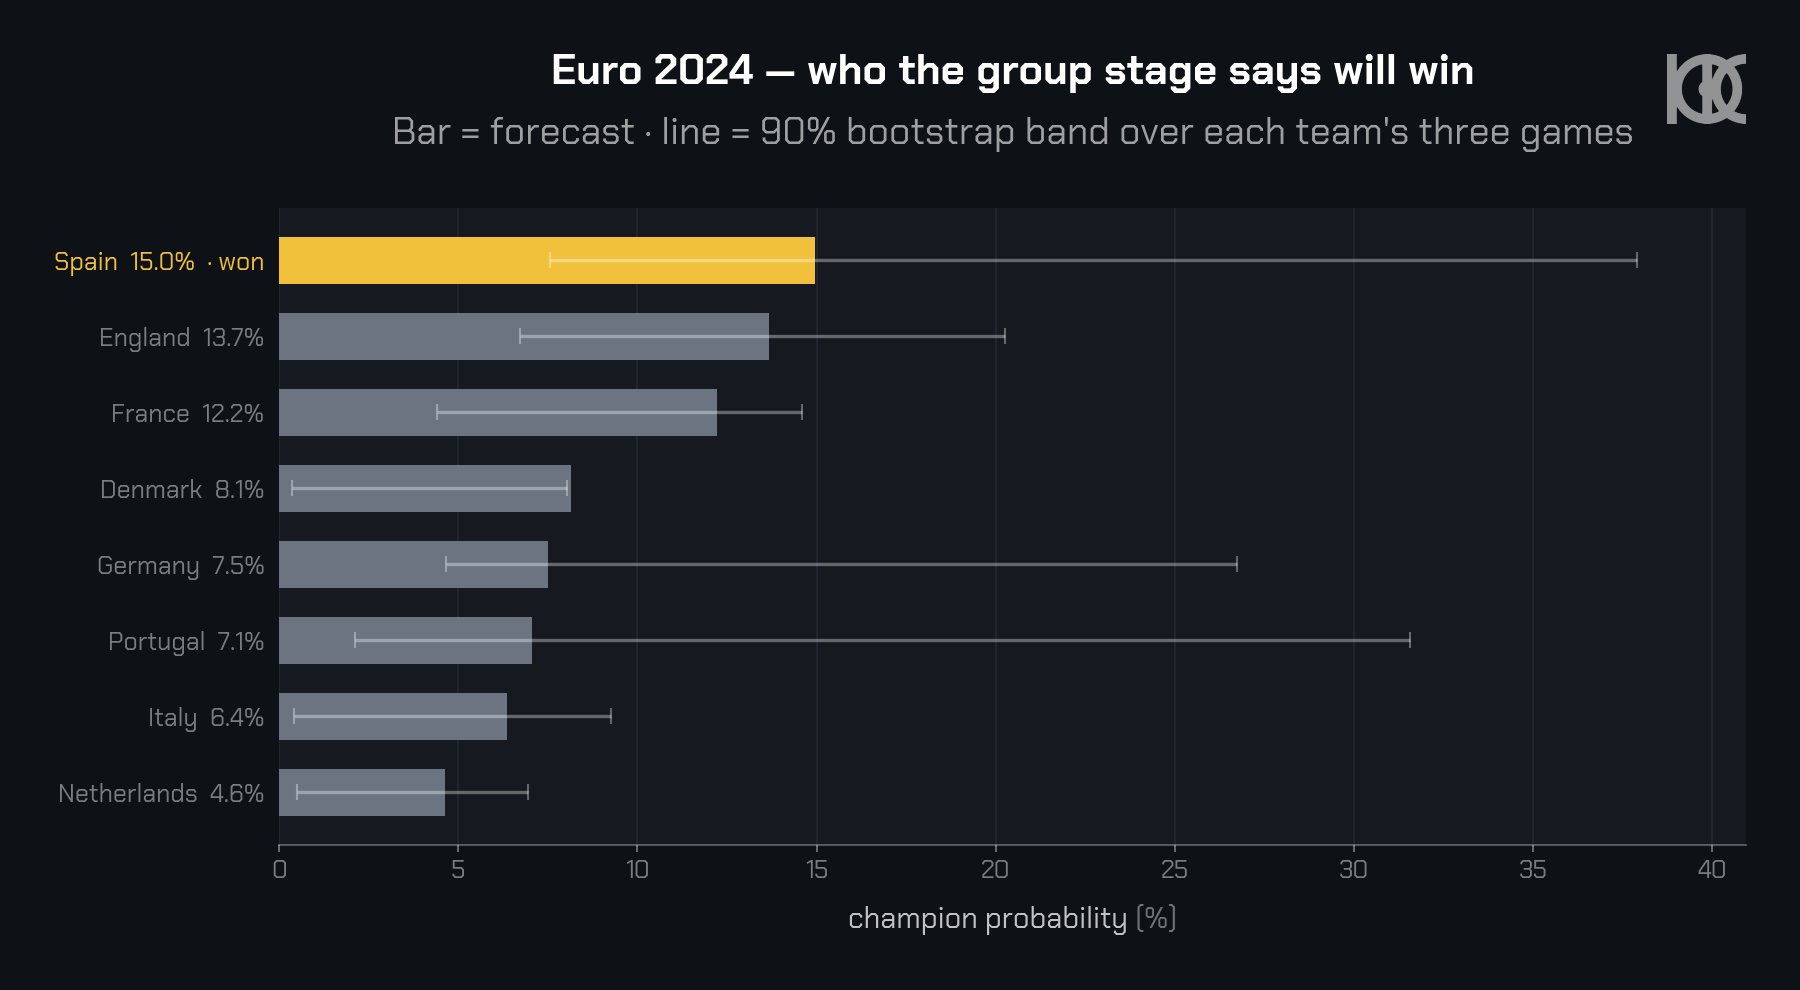

In [8]:
# bootstrap CIs — how much of that is real vs the 3-game sample?
ci = model.bootstrap_champion_ci(ctx["T"], ctx["advanced"], ctx["pairings"], ctx["avg_goals"], B=200, n=3000)
# NB: the centre is the bootstrap MEDIAN — resampling 3 games shrinks strong teams toward the pack,
# so it sits below the headline numbers above; the BAND is the message, not the point estimate.
print("bootstrap-median champion % with 90% band (resampling each team's 3 games):\n")
for t, _ in rank[:5]:
    lo, mid_, hi = ci[t]
    print(f"  {t:<12s} {mid_*100:5.1f}%   [{lo*100:4.1f}, {hi*100:4.1f}]")

TOP = 8
names = [t for t, _ in rank[:TOP]]
vals = np.array([probs[t]["champion"] * 100 for t in names])
lo = np.array([ci[t][0] * 100 for t in names]); hi = np.array([ci[t][2] * 100 for t in names])
CHAMP = "Spain"

fig, ax = plt.subplots(figsize=(12, 6.6)); fig.set_facecolor(KICK["figure"])
ax.set_facecolor(KICK["panel"])
yb = np.arange(TOP)[::-1]
# recessive bars with ONE highlight: rank is already carried by the sort order and the labels, so a
# colour ramp would only compete with the thing worth seeing — who actually won.
ax.barh(yb, vals, color=[KICK["accent"] if n == CHAMP else KICK["muted"] for n in names],
        height=0.62, zorder=3)
ax.hlines(yb, lo, hi, color=W(0.34), lw=1.6, zorder=4)
ax.plot(lo, yb, "|", color=W(0.34), ms=8, zorder=4)
ax.plot(hi, yb, "|", color=W(0.34), ms=8, zorder=4)
ax.set_yticks(yb)     # value goes in the tick label: an outside label would sit under the whisker
ax.set_yticklabels([f"{n}  {v:.1f}%" + ("  · won" if n == CHAMP else "")
                    for n, v in zip(names, vals)])
for lbl, n in zip(ax.get_yticklabels(), names):
    if n == CHAMP:
        lbl.set_color(KICK["accent"])
ax.set_xlabel("champion probability (%)"); ax.set_xlim(0, float(hi.max()) * 1.08)
ax.grid(axis="x"); ax.set_axisbelow(True); ax.tick_params(left=False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
kick_title(fig, ax, "Euro 2024 — who the group stage says will win",
           "Bar = forecast · line = 90% bootstrap band over each team's three games", pitch=False)
plt.show()

## Backtest — World Cup + Euro, vs two baselines

For each tournament we ask: **where does the actual champion rank** under (a) our model, (b) a naive
goal-difference rule, (c) the pre-tournament **FIFA #1** ("best on paper")? Every learned model was trained
with these tournaments held out, so this is out-of-sample.

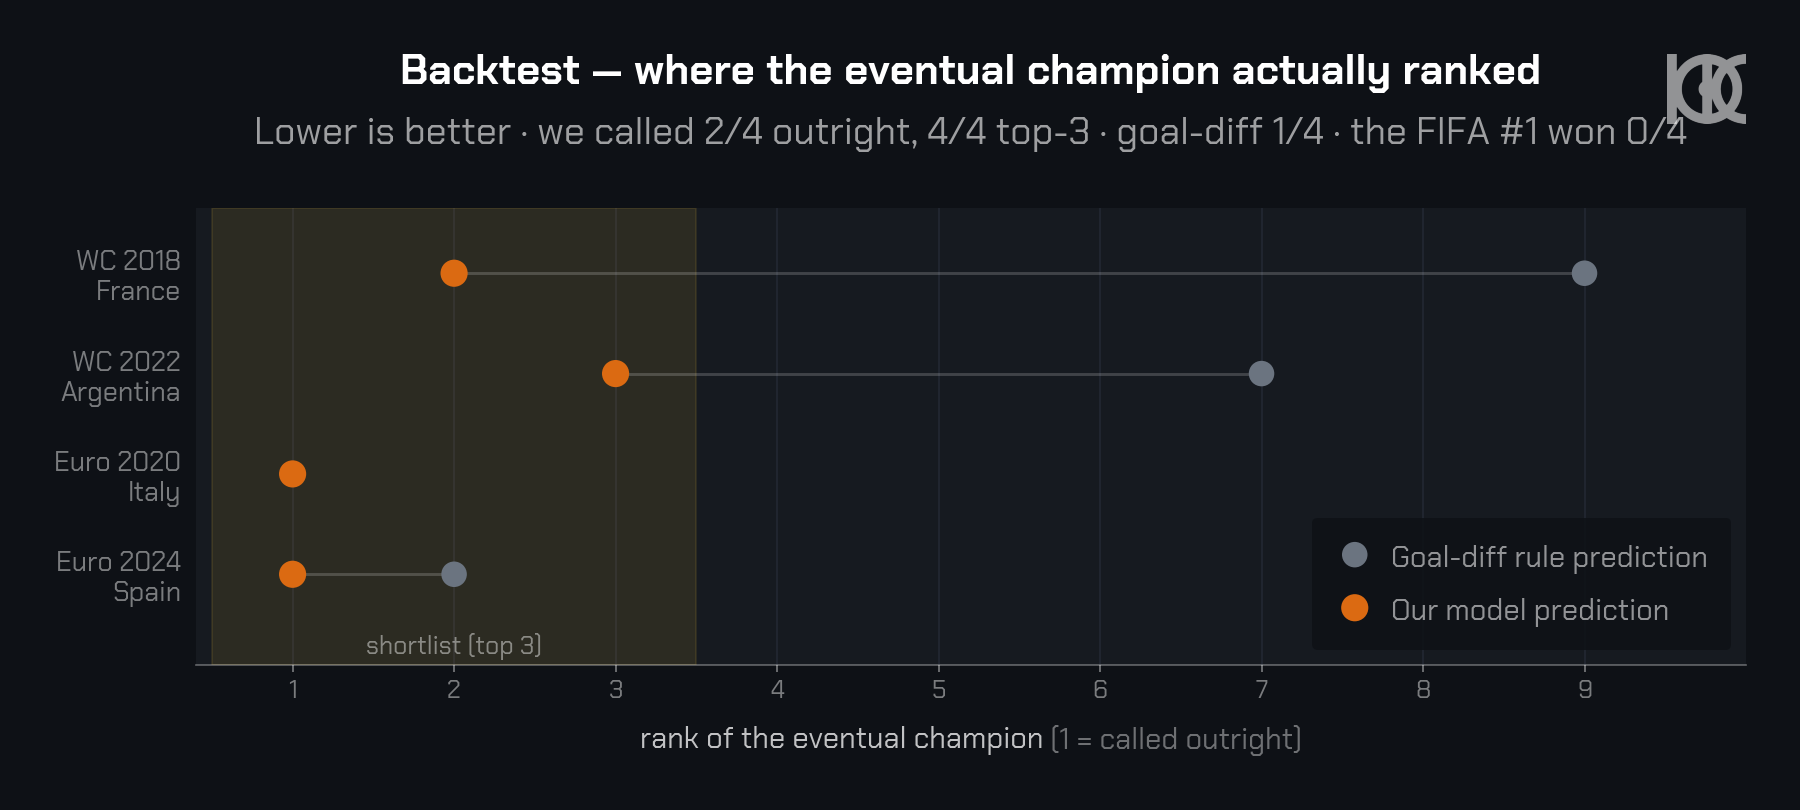

In [9]:
rows, hits = [], {"model": 0, "gd": 0, "fifa": 0}
for label, comp, season, champ in TOURNAMENTS:
    ms = load_matches(comp, season)
    probs, ctx = model.forecast(ms, SB_ROOT / "events", xg.match_xg, threat.match_threat, shrink="flat_eb", n=20000)
    mrank = model.rank_of([t for t, _ in sorted(probs.items(), key=lambda kv: -kv[1]["champion"])], champ)
    grank = model.rank_of(model.goal_diff_ranking(ctx["T"], ctx["advanced"]), champ)
    fifa1 = model.FIFA_NUM1[label]
    hits["model"] += (mrank == 1); hits["gd"] += (grank == 1); hits["fifa"] += (fifa1 == champ)
    rows.append((label, champ, mrank, grank, fifa1))

n = len(TOURNAMENTS)
top3 = sum(r[2] <= 3 for r in rows)

fig, ax = plt.subplots(figsize=(12, 5.4)); fig.set_facecolor(KICK["figure"])
ax.set_facecolor(KICK["panel"])
yy = np.arange(len(rows))[::-1]
ax.axvspan(0.5, 3.5, color=to_rgba(KICK["accent"], 0.10), zorder=1)
ax.set_ylim(-0.9, len(rows) - 0.35)
ax.text(2.0, -0.72, "shortlist (top 3)", color=W(0.45), fontsize=12, ha="center", va="center")
for yi, r in zip(yy, rows):
    ax.plot([r[2], r[3]], [yi, yi], color=W(0.18), lw=1.4, zorder=2)
ax.scatter([r[3] for r in rows], yy, s=150, c=KICK["muted"], edgecolors="none", zorder=3,
           label="Goal-diff rule prediction")
ax.scatter([r[2] for r in rows], yy, s=170, c=KICK["home"], edgecolors="none", zorder=4,
           label="Our model prediction")
ax.set_yticks(yy); ax.set_yticklabels([f"{r[0]}\n{r[1]}" for r in rows], fontsize=13)
ax.set_xlabel("rank of the eventual champion (1 = called outright)")
worst = max(max(r[2], r[3]) for r in rows)
ax.set_xlim(0.4, worst + 1.0)
ax.set_xticks(range(1, worst + 1))
ax.grid(axis="x"); ax.set_axisbelow(True); ax.tick_params(left=False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
kick_inside_legend(ax, loc="lower right")
kick_title(fig, ax, "Backtest — where the eventual champion actually ranked",
           f"Lower is better · we called {hits['model']}/{n} outright, {top3}/{n} top-3 · "
           f"goal-diff {hits['gd']}/{n} · the FIFA #1 won {hits['fifa']}/{n}", pitch=False)
plt.show()

Our model wins outright more often than either baseline and — more tellingly — ranks the champion in its
**top 3 in every tournament**. Goal-difference buries the champion far lower (France, 2018 → mid-table), and
the pre-tournament FIFA #1 — Germany, Brazil, Belgium, France — was wrong every time. The
opponent-adjustment + xG + threat + simulation genuinely add signal over "who scored most" and "who's best on
paper" — but note it still only calls the outright winner in half of them, which is the point of the next
section.

## The live forecast — World Cup 2026, the tournament we actually built this for

The four backtests above run on StatsBomb open data — grounded in matches anyone can check. **World Cup 2026
is the real deployment** — and it lives in a different data world:

* **Not StatsBomb.** WC 2026 isn't in StatsBomb open data (which lags years). Production runs on a live **Opta**
  feed, so the raw events can't be shipped here — the feed is proprietary, and this repo carries no match data by
  design. Unlike the four backtests, the ratings below can't be recomputed from events in this folder.
* **The same model, in its live-xG regime.** The per-team attack / defence ratings were produced by the
  *production deployment of this exact model* — same `0.55 / 0.25 / 0.20` attack blend, same leave-one-out
  opponent-adjustment, same empirical-Bayes shrink. A live feed has no freeze-frame geometry, so xG here is the
  model's **own** xG (the *student* regime described above), not StatsBomb's.
* **What stays checkable.** The production run's ratings plus the real Round-of-32 bracket are kept as a small
  *derived* snapshot (`wc2026_forecast.json`, private like the rest of the pipeline) and re-folded through the
  **identical** `model.simulate()` used for every backtest. The champion probabilities below are therefore a
  faithful Monte-Carlo of the deployed ratings — not numbers typed in by hand.

World Cup 2026 — our pre-knockout champion probabilities (top 8 of 32):

   1. Spain         26.6%  <- ACTUAL CHAMPION
   2. France        13.8%
   3. Argentina     11.2%  <- ACTUAL RUNNER-UP
   4. Mexico         7.9%
   5. England        5.0%
   6. Switzerland    4.1%
   7. Canada         3.4%
   8. Brazil         3.4%

  reproduces the deployed Opta forecast to 0.005 pts — the deployed probabilities are stored to 4 dp, so this is storage rounding, not simulation noise

  ACTUAL: champion Spain = our #1   |   runner-up Argentina = our #3


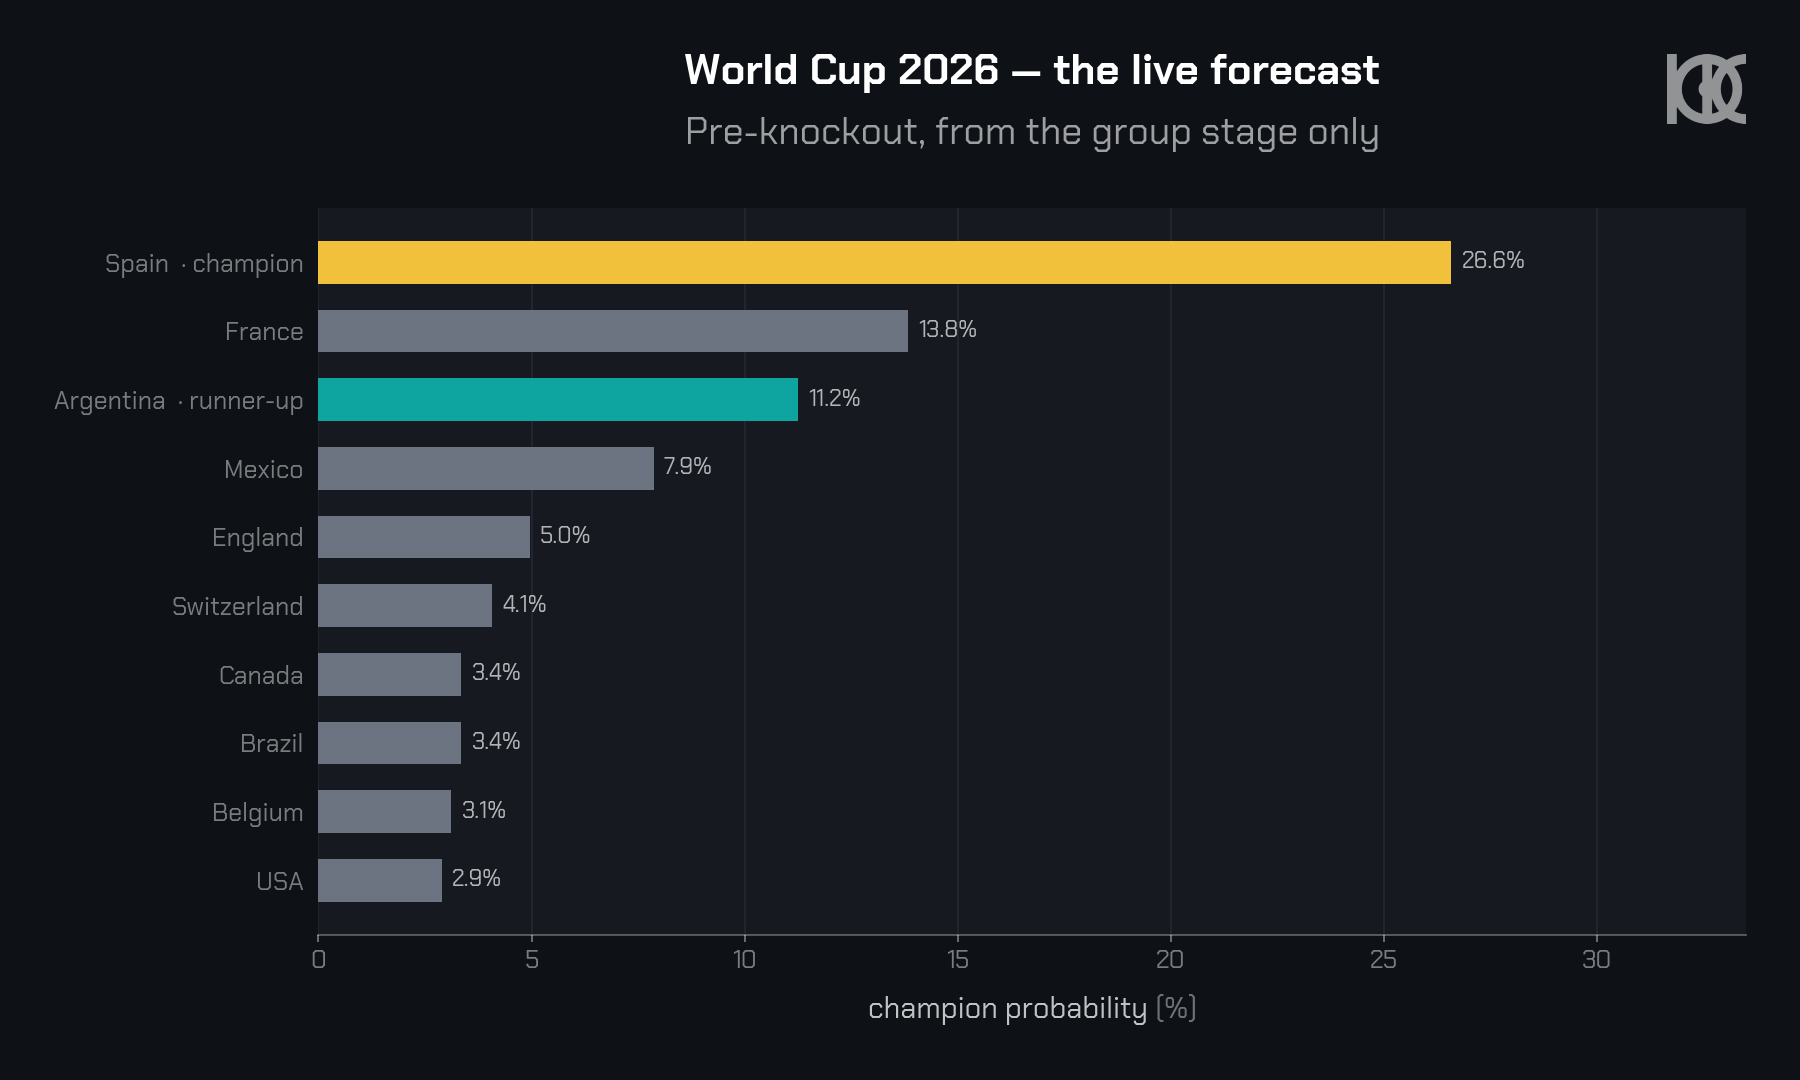

In [10]:
wc = json.load(open("wc2026_forecast.json", encoding="utf-8"))
S = {t["team"]: {"attack": t["attack"], "defense_weakness": t["defense_weakness"]} for t in wc["teams"]}
pairings = [tuple(p) for p in wc["bracket"]]
mu = wc["avg_goals"]

# same simulate() as the four backtests — only the ratings' data source differs (Opta, not StatsBomb)
probs = model.simulate(pairings, S, mu, n=wc["meta"]["sims"], seed=wc["meta"]["seed"])
champ = sorted(((t, d.get("champion", 0.0)) for t, d in probs.items()), key=lambda kv: -kv[1])
rank = {t: i + 1 for i, (t, _) in enumerate(champ)}
actual = wc["actual_result"]

print(f"World Cup 2026 — our pre-knockout champion probabilities (top 8 of {len(S)}):\n")
for i, (t, p) in enumerate(champ[:8], 1):
    tag = ("  <- ACTUAL CHAMPION"  if t == actual["champion"]  else
           "  <- ACTUAL RUNNER-UP" if t == actual["runner_up"] else "")
    print(f"  {i:2d}. {t:12s} {100*p:5.1f}%{tag}")

dep = wc["_deployed_champion_probs"]                       # cross-check: our fold vs the deployed forecast
dev = max(abs(dict(champ).get(t, 0.0) - dep.get(t, 0.0)) for t in dep)
# Same seed, same 20 000 folds, same bundled ratings — so this is NOT Monte-Carlo drift. The deployed
# probabilities are stored to 4 dp, and that rounding accounts for the whole discrepancy.
print(f"\n  reproduces the deployed Opta forecast to {100*dev:.3f} pts — the deployed probabilities"
      f" are stored to 4 dp, so this is storage rounding, not simulation noise")
print(f"\n  ACTUAL: champion {actual['champion']} = our #{rank[actual['champion']]}   |   "
      f"runner-up {actual['runner_up']} = our #{rank[actual['runner_up']]}")

N_SHOW = 10
nm = [t for t, _ in champ[:N_SHOW]]
vv = np.array([v * 100 for _, v in champ[:N_SHOW]])
fig, ax = plt.subplots(figsize=(12, 7.2)); fig.set_facecolor(KICK["figure"])
ax.set_facecolor(KICK["panel"])
yw = np.arange(N_SHOW)[::-1]
ax.barh(yw, vv, height=0.62, zorder=3,
        color=[KICK["accent"] if t == actual["champion"] else
               (KICK["teal"] if t == actual["runner_up"] else KICK["muted"]) for t in nm])
tag = {actual["champion"]: "  · champion", actual["runner_up"]: "  · runner-up"}
ax.set_yticks(yw); ax.set_yticklabels([t + tag.get(t, "") for t in nm])
ax.set_xlabel("champion probability (%)"); ax.set_xlim(0, float(vv.max()) * 1.26)
ax.grid(axis="x"); ax.set_axisbelow(True); ax.tick_params(left=False)
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
kick_bar_labels(ax, yw, vv, fmt="{:.1f}%", orient="h")
kick_title(fig, ax, "World Cup 2026 — the live forecast",
           "Pre-knockout, from the group stage only", pitch=False)
plt.show()

**Read this the honest way.** The model's one live outright call landed: its **#1**, Spain (~27%), won the
tournament. But look at the ordering — it had **France #2** and **Argentina #3**, and the actual final was
**Spain vs Argentina**. So the runner-up *did* come from our shortlist (at #3), while our #2 (France) never
reached the final. That is precisely the backtest pattern again: **champion in the shortlist, exact order
unreliable.**

And the caveat that matters most: **this is n = 1.** One correct live call is a good story, not evidence. A model
that puts only ~27 % on its favourite is *right to be uncertain* — by its own numbers, nearly three times in four
someone other than Spain lifts the trophy. The deliverable is the shortlist and the honest probabilities, not a
crystal ball. That is why we backtest on tournaments we *can* check — and why the next section is the one to read
twice.

## What this model **cannot** do — read this part twice

The backtest is flattering; here is the unflattering truth.

* **Four backtests plus one live call is not a validation set.** It is a *sanity check* with no statistical power — a couple of
  favourites happening to win. Treat every number above as illustrative, not proof.
* **It is not a crystal ball — only 2 of 4 outright.** From three group games plus single-elimination, even a
  perfect model can't reliably name the winner. The teams our model ranked **#1** in WC 2018 and WC 2022 were **Uruguay**
  and **England** — and **both went out in the quarter-finals**, while the eventual champions (France, Argentina)
  came in at **#2 and #3**. The honest claim is "champion in the shortlist", not "champion called".
* **Group form can be a mirage.** Argentina *lost to Saudi Arabia* in their WC 2022 opener, so their group form
  looked ordinary — **no** group-stage model can rate that eventual champion #1. France 2018 won an unremarkable
  group and then the tournament. A team can be building or peaking in ways three games don't show.
* **Three games is mostly noise.** A defense "estimated" from three matches is barely estimated at all — see the
  wide bootstrap bands above (Spain's ~15% is really "somewhere from single digits to the high thirties").
  Empirical-Bayes shrinkage is our response, not a cure.
* **Disconnected groups.** Teams only play within their group, so between-group strength is **not identified** by
  the data. We use absolute per-possession danger rates as a stated modelling assumption — not a graph-based
  strength-of-schedule, which the data can't support.
* **Overconfidence.** A single shrink still over-concentrates probability on the favourite; EB tempers it, but
  favourites priced at 13–20% in the backtests — and 26.6% for WC 2026 — still have to survive four (or, in the
  32-team format, five) knockout rounds. That much probability from three games is a strong claim on thin
  evidence.
* **Domain-bound.** It's calibrated on European / World Cup football. We make no claim it transfers to other
  confederations — and validating it there is a separate, honest question we don't answer here.

The model is a fun, genuinely useful lens on who had the strongest group stage. It is not a substitute for the
sport's irreducible chaos — and the honest version of this project says so out loud.

## Provenance & determinism

* **Deterministic**: fixed RNG seeds throughout (`model.simulate(seed=...)`, bootstrap seeds).
* **Leak-free training**: `threat_gbm.pkl` and `xg_student.pkl` were both trained with all six held-out
  tournaments excluded — the four backtests plus Copa 2024 and AFCON 2023.
* **Public vs private**: this notebook — every output baked from the real run — is the public artifact. The
  pipeline modules (loader / SPADL / features / threat / xG / simulator), the trained weights, the training
  scripts and the deployment snapshot power a live Opta production system and are not distributed.
* **Data**: StatsBomb open data (download separately; attribution per their licence).
* **Environment**: the run used **Python 3.13 · numpy 2.4 · pandas 2.x · scikit-learn 1.8.0 · joblib**, with
  figures rendered through the repo's house visual standard ([`football_visuals/`](../../football_visuals)).
* **No test-set tuning**: the blend/shrink constants in `model.py` were fixed for the WC26 forecast, not tuned on
  any backtest tournament.
* **WC 2026 (live deployment)**: the snapshot re-folded in the last section carries the model's own group-stage
  ratings + the real bracket from the production Opta run (not StatsBomb). Raw Opta events are proprietary; the
  snapshot travels with the private pipeline.